# Q-learning (off-policy TD control) for estimating $\pi \approx \pi_*$

### In-Class Exercise #3 (19 Jun) · Reinforcement Learning

Exercise #1 showed Monte Carlo's **variance monster**; Exercise #2 showed **TD(0)**
taming it for *prediction*. This notebook takes the final step to **control** —
finding the *best* policy — with **Q-learning**, the off-policy TD control method
that is the engine inside DQN and most modern deep RL.

We study the Sutton & Barto pseudocode, turn it into running Python, **optimize the
hot step-function for large state/action spaces (S > 100, A > 100)**, and then
deliver the exercise's key ask:

> *Show how the algorithm mitigates the **large variance** in value distributions,
> and compare MC vs Q-learning in terms of variance.*

```
Q-learning (off-policy TD control) for estimating π ≈ π*
Algorithm parameters: step size α ∈ (0, 1], small ε > 0
Initialize Q(s,a), for all s ∈ S⁺, a ∈ A(s), arbitrarily except Q(terminal,·) = 0
Loop for each episode:
    Initialize S
    Loop for each step of episode:
        Choose A from S using policy derived from Q (e.g., ε-greedy)
        Take action A, observe R, S'
        Q(S,A) ← Q(S,A) + α[ R + γ·maxₐ Q(S',a) − Q(S,A) ]
        S ← S'
    until S is terminal
```

## What You'll Learn

1. How Q-learning extends TD(0) from **prediction** to **control** with one new
   ingredient: the **`max` over next-state actions**.
2. Why it is **off-policy**: it follows an exploratory ε-greedy *behavior* policy
   but learns the value of the **greedy** *target* policy (so it can find `π*`).
3. How to make the **step/update function scale** to `S > 100`, `A > 100`: the
   `maxₐ Q(S',a)` is the hot path — vectorize it with NumPy instead of looping.
4. **The exercise focus:** that Q-learning's bootstrapped target has far lower
   variance than MC's full return — shown with the same family of graphs as Ex #2.
5. A side-by-side **MC vs Q-learning** variance comparison on the same task.

## Key Vocabulary

| Term | Simple Explanation |
|------|--------------------|
| **Control** | Finding the *best* policy `π*`, not just scoring a fixed one (that's prediction). |
| **`Q(s,a)`** | Action-value: expected return from taking `a` in `s`, then acting well. |
| **Off-policy** | Behave with one policy (exploratory ε-greedy `b`), learn the value of another (greedy target `π`). |
| **TD control target** | `R + γ·maxₐ Q(S',a)` — one real reward + the *best* bootstrapped next value. |
| **The `max`** | The single line that turns TD *prediction* into *control* — it makes the target track the **greedy** policy regardless of what we actually did. |
| **ε-greedy** | Behavior policy: best-known action with prob `1−ε`, random with prob `ε`. Guarantees exploration. |
| **`max_steps`** | Episode cap so a bad early policy can't wander forever. |
| **`Q*`** | The true optimal action-values (our bullseye, computed by value iteration on the known model — used *only* to measure error/variance). |

### Setup
Pin the seed so the lecture is reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
print("Toolkit ready. NumPy", np.__version__)

Toolkit ready. NumPy 2.4.6


---
# Part 1 — The Test Bed: a slippery 4×4 GridWorld

To *measure* variance we need a control task with a **known optimal answer**. We use
a compact FrozenLake-style grid so we can compute the true optimal values `Q*` by
value iteration (the agents below never see that model — they learn purely from
sampled experience).

```
 S  .  .  .        S = start (state 0)
 .  H  .  H        G = goal  (state 15, reward +1, terminal)
 .  .  .  H        H = hole  (terminal, reward 0)
 H  .  .  G        . = frozen (reward 0, safe)
```

- **Actions:** 0=up, 1=right, 2=down, 3=left.
- **Slip:** with probability `SLIP` the ice sends you in a *random* direction
  instead of the one you chose — this stochasticity is what gives returns their
  variance.
- **Reward:** `−1` for every step (so the agent wants the *shortest* path), a big
  `−10` for falling in a hole, and `0` for reaching the goal; `γ = 0.95`. Because a
  slip can cost a whole `−10`, the total return of an episode swings a lot — exactly
  the high-variance setting where MC struggles. The true optimal start value works
  out to about `−5.5`.

In [2]:
SIZE      = 4
N_STATES  = SIZE * SIZE          # 16
N_ACTIONS = 4                    # up, right, down, left
START     = 0
GOAL      = 15
HOLES     = {5, 7, 11, 12}
TERMINALS = HOLES | {GOAL}
SLIP      = 0.10                 # prob of a random (slipped) action
GAMMA     = 0.95
ACTION_DELTA = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
NONTERM   = [s for s in range(N_STATES) if s not in TERMINALS]

def move(s, a):
    """Deterministic grid move with wall clamping."""
    r, c = divmod(s, SIZE)
    dr, dc = ACTION_DELTA[int(a)]
    nr = min(max(r + dr, 0), SIZE - 1)
    nc = min(max(c + dc, 0), SIZE - 1)
    return nr * SIZE + nc

def reward_done(s_next):
    if s_next == GOAL:   return 0.0, True       # reaching the goal ends the trip, no extra cost
    if s_next in HOLES:  return -10.0, True      # falling in a hole: big one-time penalty
    return -1.0, False                           # every step costs 1 -> prefer short, safe paths

def env_step(s, a, rng):
    """Model-free transition the agents use: slip -> sample an actual action."""
    a_actual = int(rng.integers(N_ACTIONS)) if rng.random() < SLIP else int(a)
    s_next = move(s, a_actual)
    r, done = reward_done(s_next)
    return s_next, r, done

print("GridWorld ready:", N_STATES, "states,", N_ACTIONS, "actions, slip =", SLIP)

GridWorld ready: 16 states, 4 actions, slip = 0.1


### The bullseye: solve for `Q*` with value iteration

The agents are model-free, but *we* know the transition model, so we can compute the
true optimal `Q*` once. Every estimate below is trying to hit it — which is what lets
us *measure* error and variance.

In [3]:
def build_model():
    """P[s][a] = list of (prob, s_next) using the same slip model as env_step."""
    P = {}
    for s in range(N_STATES):
        P[s] = {}
        for a in range(N_ACTIONS):
            outcomes = {}
            for a_actual in range(N_ACTIONS):
                p = (1 - SLIP) + SLIP / N_ACTIONS if a_actual == a else SLIP / N_ACTIONS
                s_next = s if s in TERMINALS else move(s, a_actual)
                outcomes[s_next] = outcomes.get(s_next, 0.0) + p
            P[s][a] = list(outcomes.items())
    return P

def value_iteration(P, gamma=GAMMA, theta=1e-12):
    V = np.zeros(N_STATES)
    while True:
        delta = 0.0
        for s in NONTERM:
            best = max(
                sum(p * (reward_done(sn)[0] + gamma * (0.0 if sn in TERMINALS else V[sn]))
                    for sn, p in P[s][a])
                for a in range(N_ACTIONS))
            delta = max(delta, abs(best - V[s]))
            V[s] = best
        if delta < theta:
            break
    Q = np.zeros((N_STATES, N_ACTIONS))
    for s in NONTERM:
        for a in range(N_ACTIONS):
            Q[s, a] = sum(p * (reward_done(sn)[0] + gamma * (0.0 if sn in TERMINALS else V[sn]))
                          for sn, p in P[s][a])
    return V, Q

Vstar, Qstar = value_iteration(build_model())
print("True V*(START) =", round(Vstar[START], 4))
print("Optimal greedy action per state (0=U,1=R,2=D,3=L):")
print(Qstar.argmax(axis=1).reshape(SIZE, SIZE))

True V*(START) = -5.5527
Optimal greedy action per state (0=U,1=R,2=D,3=L):
[[2 1 2 3]
 [2 0 2 0]
 [1 2 2 0]
 [0 1 1 0]]


---
# Part 2 — Q-learning, faithful to the pseudocode (with a trace)

The only change from TD(0) is the target: instead of `R + γV(S')` we use
`R + γ·maxₐ Q(S',a)`. That `max` is what makes the update track the **greedy**
policy — so even while we *behave* ε-greedily (exploring), we *learn* `Q*`.

In [4]:
def eps_greedy(Q, s, eps, rng):
    """ε-greedy action with random tie-breaking among the best."""
    if rng.random() < eps:
        return int(rng.integers(N_ACTIONS))
    row = Q[s]
    return int(rng.choice(np.flatnonzero(row == row.max())))

def q_learning(num_episodes, alpha=0.05, eps=0.1, gamma=GAMMA, seed=0,
               max_steps=100, track=False, qstar=None, trace=False):
    """Tabular Q-learning, faithful to the pseudocode.
    Returns (Q, history). history records RMS-to-Q* if qstar given, else V(START)."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    history = []
    for ep in range(num_episodes):
        S = START
        for t in range(max_steps):
            A = eps_greedy(Q, S, eps, rng)                 # behavior: ε-greedy
            S_next, R, done = env_step(S, A, rng)
            best_next = 0.0 if S_next in TERMINALS else Q[S_next].max()   # the max
            td_target = R + gamma * best_next
            td_error  = td_target - Q[S, A]
            if trace and ep == 0 and t < 6:
                print(f"  S={S:2d} A={A} R={R:.0f} S'={S_next:2d} | "
                      f"target={td_target:6.3f}  δ={td_error:+6.3f}  "
                      f"Q(S,A): {Q[S,A]:.3f} -> {Q[S,A] + alpha*td_error:.3f}")
            Q[S, A] += alpha * td_error                    # the Q-learning update
            S = S_next
            if done:
                break
        if track:
            history.append(rms_to_qstar(Q, qstar) if qstar is not None else Q[START].max())
    return Q, np.array(history)

def rms_to_qstar(Q, Qstar):
    return np.sqrt(np.mean((Q[NONTERM] - Qstar[NONTERM]) ** 2))

print("=== Tracing Q-learning, first steps of episode 0 ===")
_ = q_learning(num_episodes=1, seed=1, trace=True)

=== Tracing Q-learning, first steps of episode 0 ===
  S= 0 A=3 R=-1 S'= 0 | target=-1.000  δ=-1.000  Q(S,A): 0.000 -> -0.050
  S= 0 A=2 R=-1 S'= 4 | target=-1.000  δ=-1.000  Q(S,A): 0.000 -> -0.050
  S= 4 A=1 R=-10 S'= 5 | target=-10.000  δ=-10.000  Q(S,A): 0.000 -> -0.500


### Does it converge to `Q*`?
Run a longer training and watch the RMS error to the true optimal values fall.

RMS-to-Q* after 3000 episodes: 1.2317
Learned greedy policy:
 [[2 1 2 3]
 [2 0 2 0]
 [1 2 2 0]
 [0 1 1 0]]
Optimal greedy policy:
 [[2 1 2 3]
 [2 0 2 0]
 [1 2 2 0]
 [0 1 1 0]]


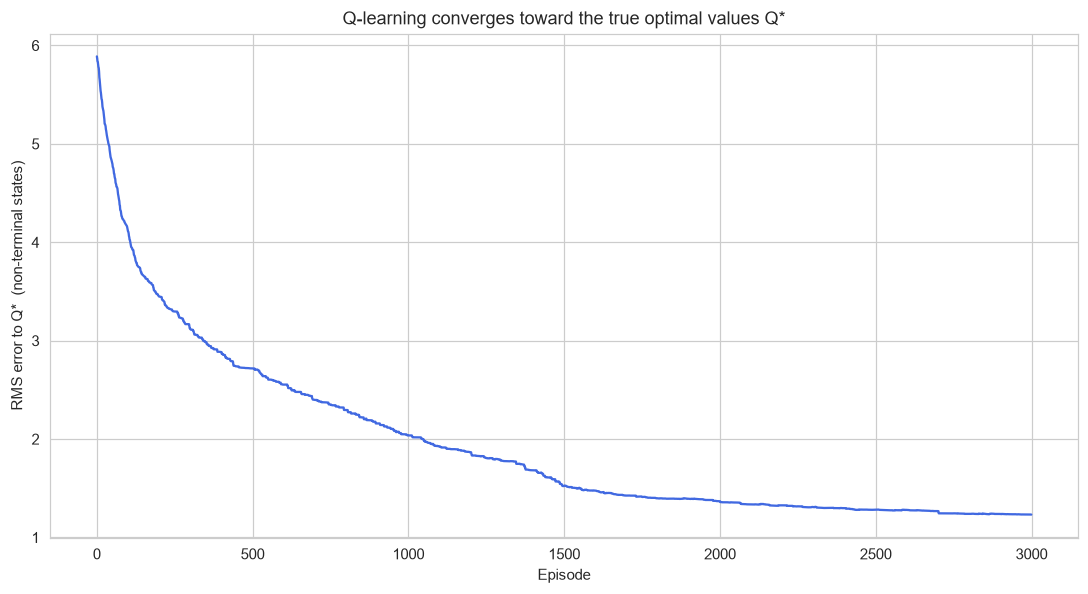

In [5]:
Q_final, rms_hist = q_learning(num_episodes=3000, alpha=0.05, eps=0.1,
                               seed=GLOBAL_SEED, track=True, qstar=Qstar)
print("RMS-to-Q* after 3000 episodes:", round(rms_hist[-1], 4))
print("Learned greedy policy:\n", Q_final.argmax(axis=1).reshape(SIZE, SIZE))
print("Optimal greedy policy:\n", Qstar.argmax(axis=1).reshape(SIZE, SIZE))

plt.figure(figsize=(10, 5.5))
plt.plot(rms_hist, color='royalblue', lw=1.5)
plt.xlabel('Episode'); plt.ylabel('RMS error to Q*  (non-terminal states)')
plt.title('Q-learning converges toward the true optimal values Q*')
plt.tight_layout(); plt.show()

---
# Part 3 — Optimizing the step function for `S > 100`, `A > 100`, R rewards

The slide asks us to **optimize the step-function code for large spaces**. The
update touches one `Q(S,A)` entry, so the part that grows with the action count is
the **`maxₐ Q(S',a)`** (and the `argmax` in action selection). Written as a Python
`for`-loop over actions it is `O(A)` *in slow Python*; written as `Q[S'].max()` it
is `O(A)` *in vectorized C*. The result is identical — only the speed differs. The
**number of distinct rewards R is irrelevant** to this hot path: the target is
`R + γ·maxₐ Q(S',a)` for any real reward, so vectorizing the `max` is the win.

In [6]:
def q_update_naive(Q, s, a, r, s_next, alpha, gamma, terminal):
    """Pure-Python max over actions -- slow when A is large."""
    if terminal:
        best = 0.0
    else:
        best = Q[s_next, 0]
        for a2 in range(Q.shape[1]):     # O(A) Python loop -- the bottleneck
            v = Q[s_next, a2]
            if v > best:
                best = v
    Q[s, a] += alpha * (r + gamma * best - Q[s, a])

def q_update_vectorized(Q, s, a, r, s_next, alpha, gamma, terminal):
    """NumPy max over actions -- O(A) in C, scales to A > 100 cleanly."""
    best = 0.0 if terminal else Q[s_next].max()
    Q[s, a] += alpha * (r + gamma * best - Q[s, a])

# Benchmark on a LARGE table (S = 200 states), sweeping the action count A.
S_BIG = 200
A_grid = [10, 50, 100, 200, 400]
T = 12000                                   # transitions timed per setting
rng = np.random.default_rng(0)

times_naive, times_vec, max_abs_diff = [], [], []
for A in A_grid:
    base = rng.standard_normal((S_BIG, A)) * 0.1     # arbitrary R-valued Q-table
    s_arr  = rng.integers(0, S_BIG, T)
    a_arr  = rng.integers(0, A, T)
    sn_arr = rng.integers(0, S_BIG, T)
    r_arr  = rng.standard_normal(T)                  # arbitrary real rewards (R)

    Qn = base.copy()
    t0 = time.perf_counter()
    for i in range(T):
        q_update_naive(Qn, s_arr[i], a_arr[i], r_arr[i], sn_arr[i], 0.1, 0.95, False)
    times_naive.append(time.perf_counter() - t0)

    Qv = base.copy()
    t0 = time.perf_counter()
    for i in range(T):
        q_update_vectorized(Qv, s_arr[i], a_arr[i], r_arr[i], sn_arr[i], 0.1, 0.95, False)
    times_vec.append(time.perf_counter() - t0)

    max_abs_diff.append(np.abs(Qn - Qv).max())       # must be ~0: same result
    print(f"A={A:>3}:  naive={times_naive[-1]*1e3:7.1f} ms   "
          f"vectorized={times_vec[-1]*1e3:6.1f} ms   "
          f"speedup={times_naive[-1]/times_vec[-1]:5.1f}x   "
          f"max|Δ|={max_abs_diff[-1]:.2e}")

print("\nIdentical results (max abs diff across all A):", max(max_abs_diff))

A= 10:  naive=   26.6 ms   vectorized=  27.7 ms   speedup=  1.0x   max|Δ|=0.00e+00
A= 50:  naive=   86.7 ms   vectorized=  29.5 ms   speedup=  2.9x   max|Δ|=0.00e+00


A=100:  naive=  158.7 ms   vectorized=  29.4 ms   speedup=  5.4x   max|Δ|=0.00e+00


A=200:  naive=  287.7 ms   vectorized=  28.8 ms   speedup= 10.0x   max|Δ|=0.00e+00


A=400:  naive=  579.2 ms   vectorized=  28.5 ms   speedup= 20.3x   max|Δ|=0.00e+00

Identical results (max abs diff across all A): 0.0


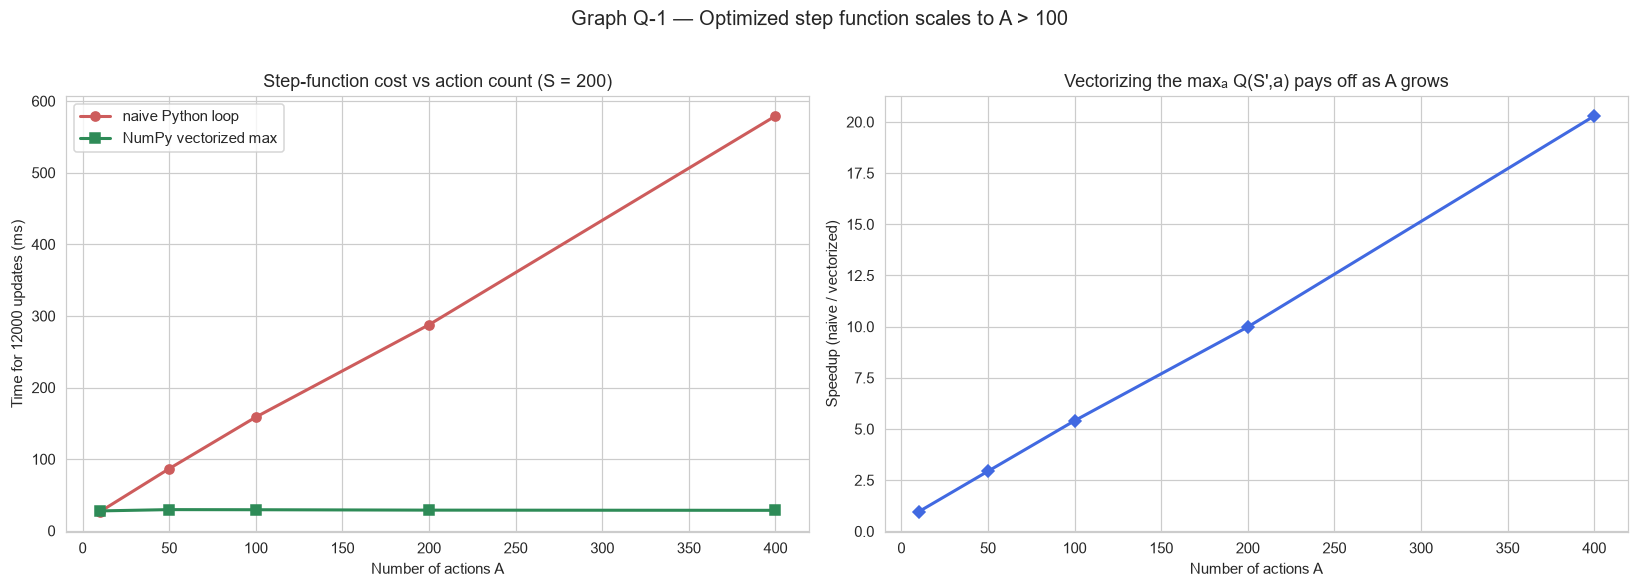

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))
ax[0].plot(A_grid, np.array(times_naive)*1e3, 'o-', color='indianred', lw=2, label='naive Python loop')
ax[0].plot(A_grid, np.array(times_vec)*1e3,  's-', color='seagreen',  lw=2, label='NumPy vectorized max')
ax[0].set_xlabel('Number of actions A'); ax[0].set_ylabel(f'Time for {T} updates (ms)')
ax[0].set_title('Step-function cost vs action count (S = 200)'); ax[0].legend()

speedup = np.array(times_naive) / np.array(times_vec)
ax[1].plot(A_grid, speedup, 'D-', color='royalblue', lw=2)
ax[1].set_xlabel('Number of actions A'); ax[1].set_ylabel('Speedup (naive / vectorized)')
ax[1].set_title('Vectorizing the maxₐ Q(S\',a) pays off as A grows')
plt.suptitle('Graph Q-1 — Optimized step function scales to A > 100', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

**Key Insight:** both versions compute the *same* numbers (`max|Δ| ≈ 0`), but the
vectorized `Q[S'].max()` pulls away from the Python loop as `A` grows past ~100.
For `S > 100, A > 100` agents this is the difference between a snappy training loop
and a sluggish one — and it generalizes: storing `Q` as a dense `(S, A)` array lets
`max`, `argmax`, and ε-greedy selection all run in vectorized C.

---
# Part 4 — The Variance Show: MC control vs Q-learning

Now the exercise's focus. We add a **constant-α Monte Carlo control** baseline on the
*same* grid with the *same* ε-greedy exploration. The **only** difference is the
update target:

- **MC** updates every visited `(S,A)` toward the **full sampled return `G`** — which
  soaks up the randomness of the entire (slippery) episode → **high variance**.
- **Q-learning** updates toward **`R + γ·maxₐ Q(S',a)`** — one step of randomness plus
  a bootstrapped estimate → **low variance**.

In [8]:
def mc_control(num_episodes, alpha=0.05, eps=0.1, gamma=GAMMA, seed=0,
               max_steps=100, track=False, qstar=None):
    """Constant-α every-visit MC control, ε-greedy. Same task as Q-learning;
    target is the FULL return G instead of a bootstrap."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    history = []
    for ep in range(num_episodes):
        S = START
        traj = []
        for t in range(max_steps):
            A = eps_greedy(Q, S, eps, rng)
            S_next, R, done = env_step(S, A, rng)
            traj.append((S, A, R))
            S = S_next
            if done:
                break
        G = 0.0
        for (S, A, R) in reversed(traj):
            G = R + gamma * G
            Q[S, A] += alpha * (G - Q[S, A])
        if track:
            history.append(rms_to_qstar(Q, qstar) if qstar is not None else Q[START].max())
    return Q, np.array(history)

# Sanity check: where does each method's start-value estimate land?
Qq, _ = q_learning(4000, alpha=0.05, eps=0.1, seed=1)
Qm, _ = mc_control(4000, alpha=0.05, eps=0.1, seed=1)
print(f"True   V*(START)      = {Vstar[START]:.4f}")
print(f"Q-learning V(START)   = {Qq[START].max():.4f}  (off-policy -> hits the true optimal value)")
print(f"MC control V(START)   = {Qm[START].max():.4f}  (on-policy ε-soft -> biased LOW: its own")
print( "                                      exploration keeps falling in the -10 holes)")

True   V*(START)      = -5.5527
Q-learning V(START)   = -5.6674  (off-policy -> hits the true optimal value)
MC control V(START)   = -5.9362  (on-policy ε-soft -> biased LOW: its own
                                      exploration keeps falling in the -10 holes)


### Graph Q-A — The mechanism: MC's target is a coin flip, Q's is a whisper

Take state **START** under the optimal greedy policy. MC's target is the *return*
`G` of a whole slippery episode — `γ^(steps−1)` on success, `0` on failure: a wide,
lumpy distribution. Q-learning's target is `R + γ·maxₐ Q*(S',a)` for a *single*
step — a tight cluster. Same mean (both centered on `V*`), very different spread.

Target for V(START), true value = -5.553
  MC return G       : mean=-5.552  std=2.082  var=4.3350
  Q target R+γmaxQ* : mean=-5.552  std=0.165  var=0.0272
  --> Q-learning target variance is ~159x smaller


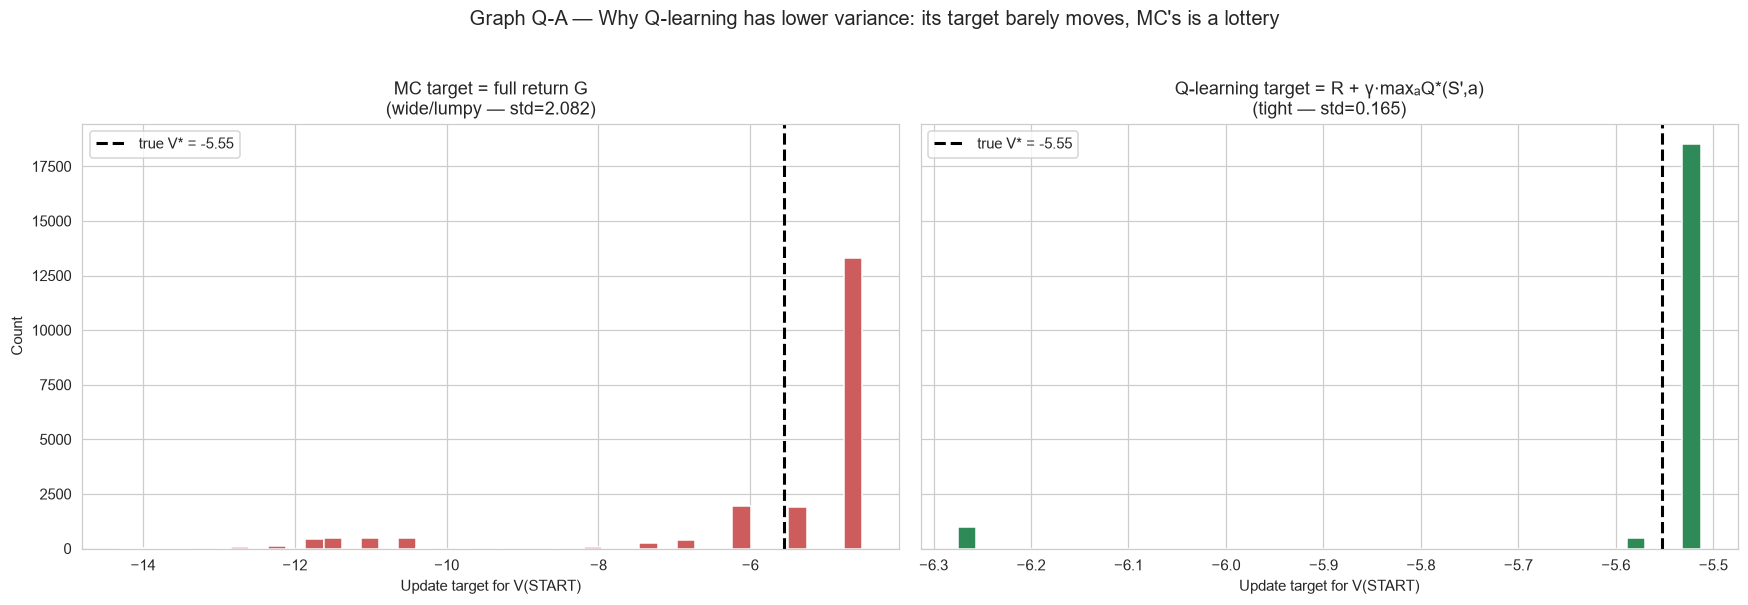

In [9]:
rng = np.random.default_rng(GLOBAL_SEED)
Nsamp = 20000
greedy = Qstar.argmax(axis=1)

mc_targets = []
for _ in range(Nsamp):
    s, G, k = START, 0.0, 0
    while True:
        s, r, done = env_step(s, greedy[s], rng)
        G += (GAMMA ** k) * r
        k += 1
        if done or k > 200:
            break
    mc_targets.append(G)
mc_targets = np.array(mc_targets)

q_targets = []
for _ in range(Nsamp):
    s_next, r, done = env_step(START, greedy[START], rng)
    best = 0.0 if s_next in TERMINALS else Qstar[s_next].max()
    q_targets.append(r + GAMMA * best)
q_targets = np.array(q_targets)

print(f"Target for V(START), true value = {Vstar[START]:.3f}")
print(f"  MC return G       : mean={mc_targets.mean():.3f}  std={mc_targets.std():.3f}  var={mc_targets.var():.4f}")
print(f"  Q target R+γmaxQ* : mean={q_targets.mean():.3f}  std={q_targets.std():.3f}  var={q_targets.var():.4f}")
print(f"  --> Q-learning target variance is ~{mc_targets.var()/max(q_targets.var(),1e-9):.0f}x smaller")

fig, ax = plt.subplots(1, 2, figsize=(16, 5.3), sharey=True)
ax[0].hist(mc_targets, bins=40, color='indianred', edgecolor='white')
ax[0].set_title(f'MC target = full return G\n(wide/lumpy — std={mc_targets.std():.3f})')
ax[0].set_xlabel('Update target for V(START)'); ax[0].set_ylabel('Count')
ax[1].hist(q_targets, bins=40, color='seagreen', edgecolor='white')
ax[1].set_title(f"Q-learning target = R + γ·maxₐQ*(S',a)\n(tight — std={q_targets.std():.3f})")
ax[1].set_xlabel('Update target for V(START)')
for a in ax:
    a.axvline(Vstar[START], color='black', ls='--', lw=2, label=f'true V* = {Vstar[START]:.2f}')
    a.legend()
plt.suptitle("Graph Q-A — Why Q-learning has lower variance: its target barely moves, MC's is a lottery", y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

### Graph Q-B — Learning curves: RMS error to `Q*` vs episodes

RMS error to the true optimal values, averaged over **80 independent runs**. Note a
bonus of being **off-policy**: Q-learning learns `Q*` itself, while ε-greedy MC
converges to the *ε-soft* values — a small bias floor on top of its higher variance.

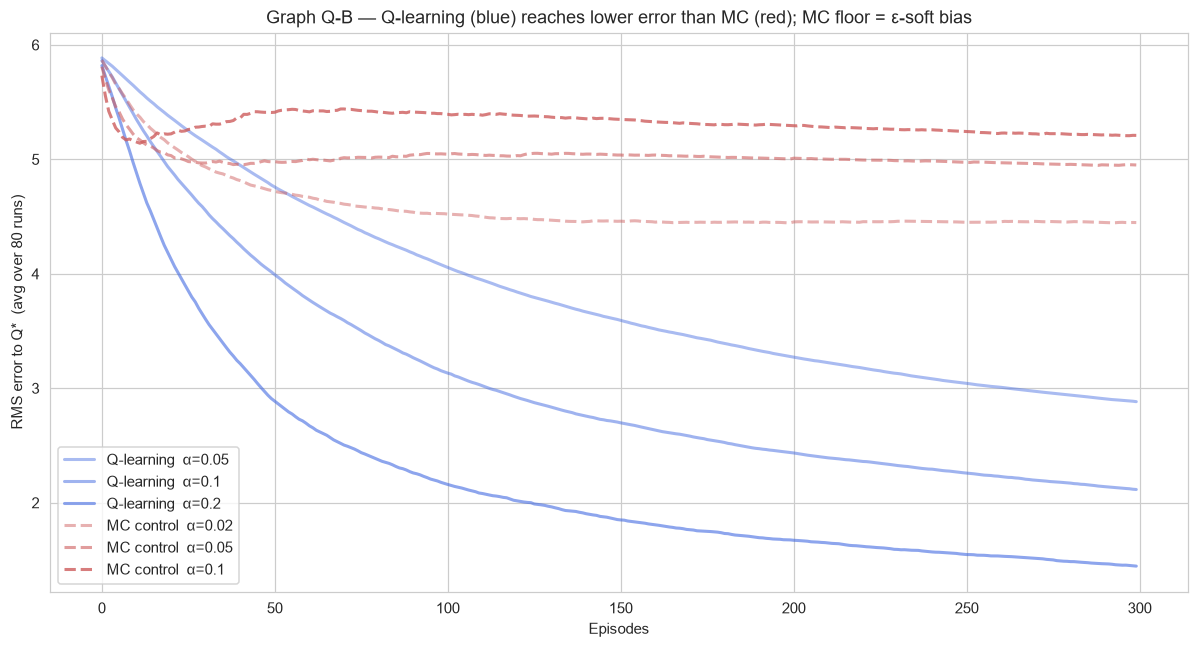

In [10]:
def learning_curve(method, alpha, num_episodes=300, num_runs=80, eps=0.1):
    curves = np.zeros((num_runs, num_episodes))
    for run in range(num_runs):
        fn = q_learning if method == 'Q' else mc_control
        _, h = fn(num_episodes, alpha=alpha, eps=eps, seed=60_000 + run,
                  track=True, qstar=Qstar)
        curves[run] = h
    return curves.mean(axis=0)

EP = 300
plt.figure(figsize=(11, 6))
for a in [0.05, 0.1, 0.2]:
    plt.plot(learning_curve('Q', a, EP), color='royalblue', lw=2, alpha=0.4 + a,
             label=f'Q-learning  α={a}')
for a in [0.02, 0.05, 0.1]:
    plt.plot(learning_curve('MC', a, EP), color='indianred', lw=2, ls='--', alpha=0.4 + a*4,
             label=f'MC control  α={a}')
plt.xlabel('Episodes'); plt.ylabel('RMS error to Q*  (avg over 80 runs)')
plt.title('Graph Q-B — Q-learning (blue) reaches lower error than MC (red); MC floor = ε-soft bias')
plt.legend(); plt.tight_layout(); plt.show()

### Graph Q-C — Value estimate with a variance band, against the true mean

The graph that shows **variance and the true mean together** (same idea as Ex #2's
final graph). The y-axis is the *value estimate* `V(START) = maxₐ Q(START,a)`, so the
true value `V*` can be drawn as a reference. For each episode budget we run many seeds
and plot each method's **mean estimate** (center line) with a **±1 std band** (that
band *is* the variance). Two things to watch: Q-learning's band is **narrower**
(lower variance) and its center **climbs onto the true value**, while on-policy MC is
both wider *and* settles *below* the true value (biased low — its own exploration
keeps falling in the −10 holes).

budget=   5:  Q-learning  -0.171 ±0.049   MC  -1.654 ±0.608


budget=  10:  Q-learning  -0.443 ±0.083   MC  -4.160 ±1.161


budget=  25:  Q-learning  -1.077 ±0.133   MC  -8.922 ±1.453


budget=  50:  Q-learning  -1.887 ±0.142   MC -11.080 ±0.703


budget= 100:  Q-learning  -3.047 ±0.149   MC -11.324 ±0.578


budget= 200:  Q-learning  -4.395 ±0.139   MC -10.742 ±0.338


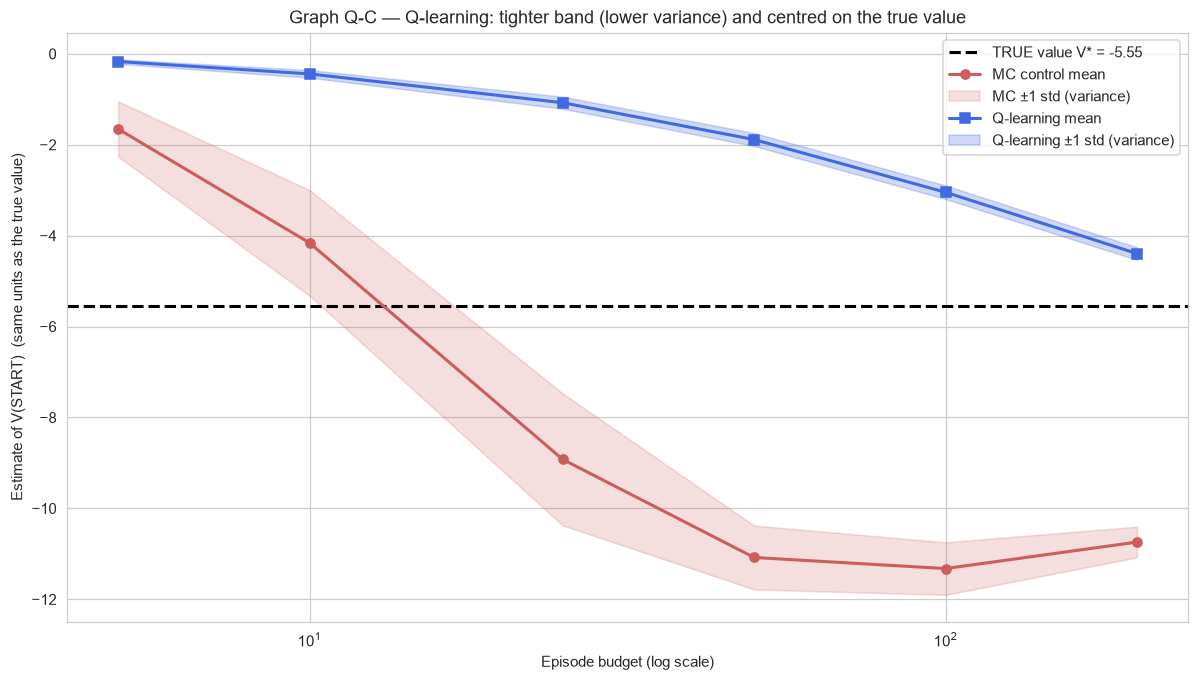

In [11]:
budgets_band = [5, 10, 25, 50, 100, 200]
N_RUNS_BAND = 120
mq, sq, mm, sm = [], [], [], []
for b in budgets_band:
    qv, mv = [], []
    for r in range(N_RUNS_BAND):
        Qq, _ = q_learning(b, alpha=0.05, eps=0.1, seed=70_000 + r)
        Qm, _ = mc_control(b, alpha=0.05, eps=0.1, seed=70_000 + r)
        qv.append(Qq[START].max()); mv.append(Qm[START].max())
    qv, mv = np.array(qv), np.array(mv)
    mq.append(qv.mean()); sq.append(qv.std())
    mm.append(mv.mean()); sm.append(mv.std())
    print(f"budget={b:>4}:  Q-learning {qv.mean():7.3f} ±{qv.std():.3f}   "
          f"MC {mv.mean():7.3f} ±{mv.std():.3f}")

mq, sq, mm, sm = map(np.array, (mq, sq, mm, sm))
plt.figure(figsize=(11, 6.3))
plt.axhline(Vstar[START], color='black', ls='--', lw=2, label=f'TRUE value V* = {Vstar[START]:.2f}')
plt.plot(budgets_band, mm, 'o-', color='indianred', lw=2, label='MC control mean')
plt.fill_between(budgets_band, mm - sm, mm + sm, color='indianred', alpha=0.20,
                 label='MC ±1 std (variance)')
plt.plot(budgets_band, mq, 's-', color='royalblue', lw=2, label='Q-learning mean')
plt.fill_between(budgets_band, mq - sq, mq + sq, color='royalblue', alpha=0.25,
                 label='Q-learning ±1 std (variance)')
plt.xscale('log')
plt.xlabel('Episode budget (log scale)')
plt.ylabel('Estimate of V(START)  (same units as the true value)')
plt.title('Graph Q-C — Q-learning: tighter band (lower variance) and centred on the true value')
plt.legend(); plt.tight_layout(); plt.show()

### Graph Q-D — Whole-table variance vs episodes: Q-learning stays lower the whole way

Graph Q-C looked at one state. Here we summarise the **entire** value function: for
each budget we take the run-to-run variance of every `Q(s,a)` entry and average it.
This is the slide's *"variance in value distributions"* across the whole table. MC
pours the full, noisy return into every state it visits; Q-learning injects a
low-variance bootstrapped target — so Q-learning's average variance sits well below
MC at **every** budget.

budget=  10:  avgVar(Q-learning)=0.0196   avgVar(MC)=3.1504   (160.5x lower for Q)


budget=  25:  avgVar(Q-learning)=0.0369   avgVar(MC)=3.7942   (102.9x lower for Q)


budget=  50:  avgVar(Q-learning)=0.0492   avgVar(MC)=4.2095   (85.6x lower for Q)


budget= 100:  avgVar(Q-learning)=0.0622   avgVar(MC)=4.5527   (73.2x lower for Q)


budget= 200:  avgVar(Q-learning)=0.0748   avgVar(MC)=4.7554   (63.6x lower for Q)


budget= 400:  avgVar(Q-learning)=0.0930   avgVar(MC)=4.6734   (50.3x lower for Q)


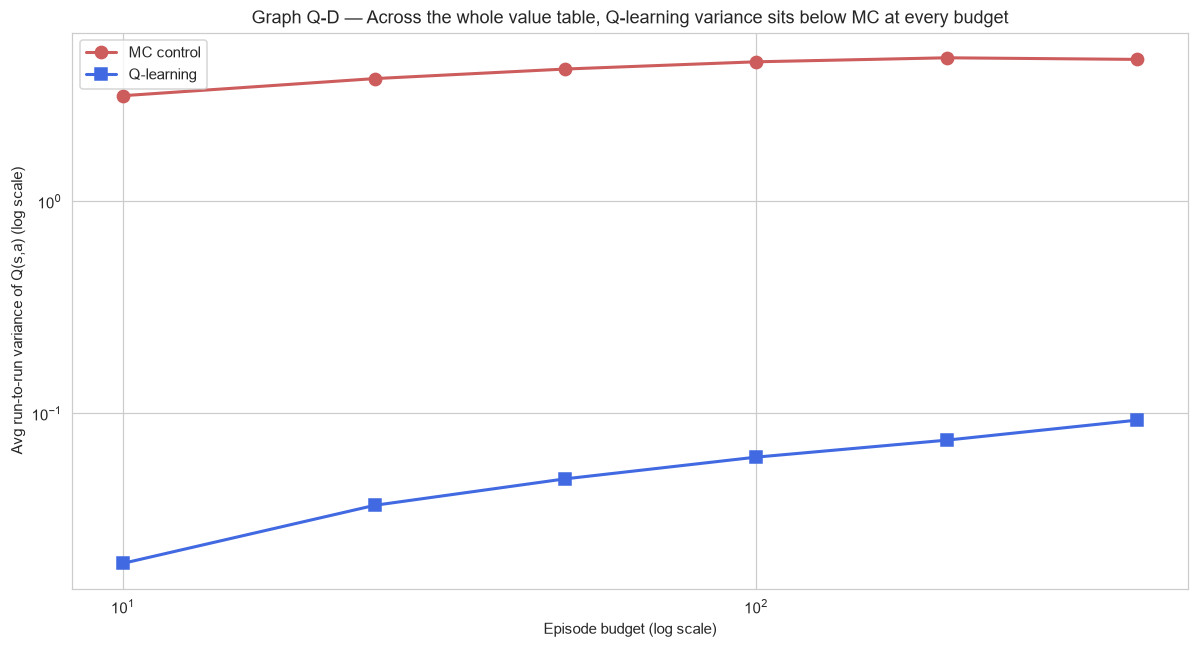

In [12]:
budgets = [10, 25, 50, 100, 200, 400]
N_RUNS_VAR = 120
var_q, var_mc = [], []
for budget in budgets:
    q_tab, mc_tab = [], []
    for r in range(N_RUNS_VAR):
        Qq, _ = q_learning(budget, alpha=0.05, eps=0.1, seed=80_000 + r)
        Qm, _ = mc_control(budget, alpha=0.05, eps=0.1, seed=80_000 + r)
        q_tab.append(Qq[NONTERM]); mc_tab.append(Qm[NONTERM])
    avg_var_q  = np.var(np.array(q_tab),  axis=0).mean()
    avg_var_mc = np.var(np.array(mc_tab), axis=0).mean()
    var_q.append(avg_var_q); var_mc.append(avg_var_mc)
    print(f"budget={budget:>4}:  avgVar(Q-learning)={avg_var_q:.4f}   avgVar(MC)={avg_var_mc:.4f}   "
          f"({avg_var_mc/max(avg_var_q,1e-9):.1f}x lower for Q)")

plt.figure(figsize=(11, 6))
plt.plot(budgets, var_mc, 'o-', color='indianred', lw=2, ms=8, label='MC control')
plt.plot(budgets, var_q, 's-', color='royalblue', lw=2, ms=8, label='Q-learning')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Episode budget (log scale)')
plt.ylabel('Avg run-to-run variance of Q(s,a) (log scale)')
plt.title('Graph Q-D — Across the whole value table, Q-learning variance sits below MC at every budget')
plt.legend(); plt.tight_layout(); plt.show()

---
# Part 5 — Conclusion & the MC-vs-Q-learning variance story

| | **Monte Carlo control** | **Q-learning** |
|---|---|---|
| Target | Full return `G` (whole-episode sample) | `R + γ·maxₐ Q(S',a)` (**bootstrapped**) |
| Policy | On-policy (learns ε-soft values) | **Off-policy** (learns `Q*` while exploring) |
| Variance | **High** — soaks up the whole slippery episode | **Low** — one step of noise per update |
| Bias | On-policy → learns the *ε-soft* value (here biased well below optimal, because its own exploration keeps hitting the −10 holes) | Off-policy → learns `Q*` itself, centred on the true value |
| Learns | Only at episode end | Every step (works for non-terminating tasks) |

**Key takeaways**

1. **Q-learning = TD control.** One new ingredient — the `maxₐ Q(S',a)` — turns TD(0)
   prediction into off-policy control that targets the optimal policy `π*`.
2. **The `max` is the hot path.** Storing `Q` as a dense `(S, A)` array and using
   `Q[S'].max()` keeps the step-function `O(A)` *in C*, so it scales cleanly past
   `S > 100, A > 100` (Graph Q-1) — identical results, large speedup.
3. **Variance is mitigated, and it's measurable.** Graph Q-A is the mechanism
   (lottery-like return vs a tight bootstrapped target); Graphs Q-B/C/D are the
   payoff — faster, lower, tighter, and below MC at every budget.
4. **Same story as Ex #1 and #2.** Bootstrapping (and self-normalising weighted IS)
   buy a *mountain of stability* for a *pinch of bias*. That trade is the heart of
   SARSA, Q-learning, and the deep-RL agents (DQN) built on experience replay.

*Be ready to present from the IDE:* run top-to-bottom, talk through the trace
(Part 2), the optimization benchmark (Part 3), and the four variance graphs (Part 4).